In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn import svm
from mlxtend.plotting import plot_decision_regions
import numpy as np
%matplotlib inline

In [5]:
df = pd.read_csv('/content/ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
df.drop('UDI', axis=1, inplace=True)
df.head()

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
df.drop('Product ID', axis=1, inplace=True)
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [8]:
df.drop(['TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1, inplace=True)
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


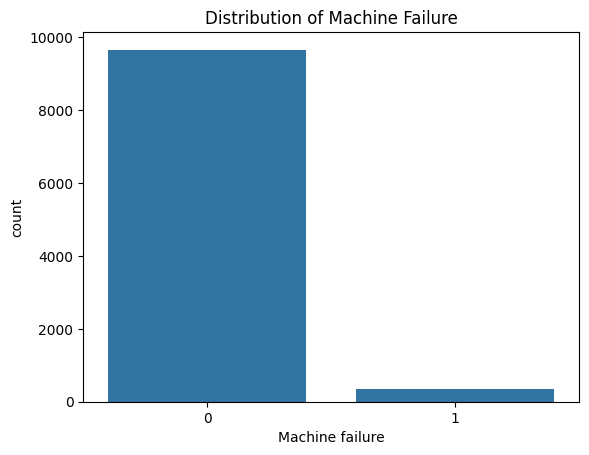

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Machine failure', data=df)
plt.title('Distribution of Machine Failure')
plt.show()

In [10]:
failure_count = df['Machine failure'].sum()
total_rows = len(df)
failure_percentage = (failure_count / total_rows) * 100

print(f"Total Machine Failures: {failure_count}")
print(f"Percentage of Machine Failures: {failure_percentage:.2f}%")

Total Machine Failures: 339
Percentage of Machine Failures: 3.39%


In [11]:
print("Null values in each column:")
print(df.isnull().sum())

print("\nData types of each column:")
print(df.dtypes)

Null values in each column:
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
dtype: int64

Data types of each column:
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
dtype: object


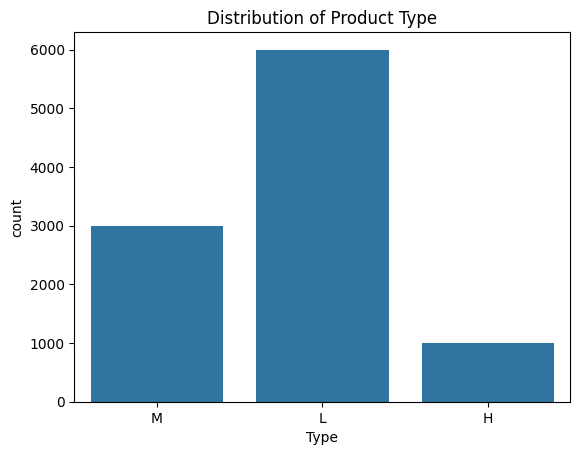

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Type', data=df)
plt.title('Distribution of Product Type')
plt.show()

In [14]:
numerical_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    print(f"Outliers in '{col}' capped using IQR method.")

print("\nDataFrame after outlier capping:")
df.head()

Outliers in 'Air temperature [K]' capped using IQR method.
Outliers in 'Process temperature [K]' capped using IQR method.
Outliers in 'Rotational speed [rpm]' capped using IQR method.
Outliers in 'Torque [Nm]' capped using IQR method.
Outliers in 'Tool wear [min]' capped using IQR method.

DataFrame after outlier capping:


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551.0,42.8,0.0,0
1,L,298.2,308.7,1408.0,46.3,3.0,0
2,L,298.1,308.5,1498.0,49.4,5.0,0
3,L,298.2,308.6,1433.0,39.5,7.0,0
4,L,298.2,308.7,1408.0,40.0,9.0,0


In [15]:
df.drop('Type', axis=1, inplace=True)
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,298.1,308.6,1551.0,42.8,0.0,0
1,298.2,308.7,1408.0,46.3,3.0,0
2,298.1,308.5,1498.0,49.4,5.0,0
3,298.2,308.6,1433.0,39.5,7.0,0
4,298.2,308.7,1408.0,40.0,9.0,0


In [16]:
from sklearn.model_selection import train_test_split

X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (8000, 5)
Shape of X_test: (2000, 5)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("First 5 rows of X_train_scaled:\n", X_train_scaled[:5])

X_train_scaled shape: (8000, 5)
X_test_scaled shape: (2000, 5)
First 5 rows of X_train_scaled:
 [[0.32608696 0.41975309 0.60881735 0.33639706 0.77075099]
 [0.31521739 0.33333333 0.28971309 0.75367647 0.54150198]
 [0.31521739 0.25925926 0.4856543  0.33639706 0.76679842]
 [0.60869565 0.62962963 0.58502449 0.37132353 0.02766798]
 [0.66304348 0.59259259 0.54583625 0.38786765 0.82213439]]


In [18]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report

# Filter X_train_scaled for normal samples (where y_train is 0)
X_train_normal = X_train_scaled[y_train == 0]

# Initialize One-Class SVM model
# nu is an upper bound on the fraction of training errors and a lower bound of the fraction of support vectors
# Given a failure rate of 3.39%, let's set nu slightly higher, e.g., 0.05
ocsvm = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')

# Train the OCSVM model on the normal training data
ocsvm.fit(X_train_normal)

# --- Evaluate on Test Data ---
# Predict on the test data
y_pred_ocsvm_test = ocsvm.predict(X_test_scaled)

# Convert OCSVM predictions (1 for inlier, -1 for outlier) to binary labels (0 for normal, 1 for anomaly)
y_pred_binary_test = np.where(y_pred_ocsvm_test == 1, 0, 1)

# Print the classification report for test data
print("Classification Report for One-Class SVM (Test Data):")
print(classification_report(y_test, y_pred_binary_test))

# --- Evaluate on Training Data ---
# Predict on the training data
y_pred_ocsvm_train = ocsvm.predict(X_train_scaled)

# Convert OCSVM predictions (1 for inlier, -1 for outlier) to binary labels (0 for normal, 1 for anomaly)
y_pred_binary_train = np.where(y_pred_ocsvm_train == 1, 0, 1)

# Print the classification report for training data
print("\nClassification Report for One-Class SVM (Training Data):")
print(classification_report(y_train, y_pred_binary_train))

Classification Report for One-Class SVM (Test Data):
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1939
           1       0.24      0.54      0.33        61

    accuracy                           0.93      2000
   macro avg       0.61      0.74      0.65      2000
weighted avg       0.96      0.93      0.95      2000


Classification Report for One-Class SVM (Training Data):
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      7722
           1       0.27      0.50      0.35       278

    accuracy                           0.93      8000
   macro avg       0.62      0.73      0.66      8000
weighted avg       0.96      0.93      0.94      8000



In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Initialize K-NN model
# A common choice for n_neighbors is 5, but this can be tuned.
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the K-NN model
knn_model.fit(X_train_scaled, y_train)

# --- Evaluate on Test Data ---
# Predict on the test data
y_pred_knn_test = knn_model.predict(X_test_scaled)

# Print the classification report for test data
print("Classification Report for K-NN (Test Data):")
print(classification_report(y_test, y_pred_knn_test))

# --- Evaluate on Training Data ---
# Predict on the training data
y_pred_knn_train = knn_model.predict(X_train_scaled)

# Print the classification report for training data
print("\nClassification Report for K-NN (Training Data):")
print(classification_report(y_train, y_pred_knn_train))

Classification Report for K-NN (Test Data):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.79      0.31      0.45        61

    accuracy                           0.98      2000
   macro avg       0.89      0.65      0.72      2000
weighted avg       0.97      0.98      0.97      2000


Classification Report for K-NN (Training Data):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      7722
           1       0.89      0.46      0.60       278

    accuracy                           0.98      8000
   macro avg       0.93      0.73      0.80      8000
weighted avg       0.98      0.98      0.98      8000



In [20]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

# Initialize Isolation Forest model
# contamination is the estimated proportion of outliers in the data set
# Since our failure rate is 3.39%, we can set contamination to a similar value or slightly higher
isolation_forest = IsolationForest(contamination=0.035, random_state=42)

# Train the Isolation Forest model on the training data
isolation_forest.fit(X_train_scaled)

# --- Evaluate on Test Data ---
# Predict on the test data
y_pred_if_test = isolation_forest.predict(X_test_scaled)

# Convert Isolation Forest predictions (1 for inlier, -1 for outlier) to binary labels (0 for normal, 1 for anomaly)
y_pred_binary_if_test = np.where(y_pred_if_test == 1, 0, 1)

# Print the classification report for test data
print("Classification Report for Isolation Forest (Test Data):")
print(classification_report(y_test, y_pred_binary_if_test))

# --- Evaluate on Training Data ---
# Predict on the training data
y_pred_if_train = isolation_forest.predict(X_train_scaled)

# Convert Isolation Forest predictions (1 for inlier, -1 for outlier) to binary labels (0 for normal, 1 for anomaly)
y_pred_binary_if_train = np.where(y_pred_if_train == 1, 0, 1)

# Print the classification report for training data
print("\nClassification Report for Isolation Forest (Training Data):")
print(classification_report(y_train, y_pred_binary_if_train))

Classification Report for Isolation Forest (Test Data):
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1939
           1       0.17      0.18      0.18        61

    accuracy                           0.95      2000
   macro avg       0.57      0.58      0.57      2000
weighted avg       0.95      0.95      0.95      2000


Classification Report for Isolation Forest (Training Data):
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      7722
           1       0.19      0.19      0.19       278

    accuracy                           0.94      8000
   macro avg       0.58      0.58      0.58      8000
weighted avg       0.94      0.94      0.94      8000



In [21]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# Initialize Gradient Boosting Classifier model
gbc_model = GradientBoostingClassifier(random_state=42)

# Train the GBoost model
gbc_model.fit(X_train_scaled, y_train)

# --- Evaluate on Test Data ---
# Predict on the test data
y_pred_gbc_test = gbc_model.predict(X_test_scaled)

# Print the classification report for test data
print("Classification Report for Gradient Boosting (Test Data):")
print(classification_report(y_test, y_pred_gbc_test))

# --- Evaluate on Training Data ---
# Predict on the training data
y_pred_gbc_train = gbc_model.predict(X_train_scaled)

# Print the classification report for training data
print("\nClassification Report for Gradient Boosting (Training Data):")
print(classification_report(y_train, y_pred_gbc_train))

Classification Report for Gradient Boosting (Test Data):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.82      0.61      0.70        61

    accuracy                           0.98      2000
   macro avg       0.90      0.80      0.84      2000
weighted avg       0.98      0.98      0.98      2000


Classification Report for Gradient Boosting (Training Data):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      7722
           1       0.96      0.76      0.85       278

    accuracy                           0.99      8000
   macro avg       0.98      0.88      0.92      8000
weighted avg       0.99      0.99      0.99      8000



In [22]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# Initialize LGBM Classifier model
lgbm_model = LGBMClassifier(random_state=42)

# Train the LGBM model
lgbm_model.fit(X_train_scaled, y_train)

# --- Evaluate on Test Data ---
# Predict on the test data
y_pred_lgbm_test = lgbm_model.predict(X_test_scaled)

# Print the classification report for test data
print("Classification Report for LGBM (Test Data):")
print(classification_report(y_test, y_pred_lgbm_test))

# --- Evaluate on Training Data ---
# Predict on the training data
y_pred_lgbm_train = lgbm_model.predict(X_train_scaled)

# Print the classification report for training data
print("\nClassification Report for LGBM (Training Data):")
print(classification_report(y_train, y_pred_lgbm_train))

[LightGBM] [Info] Number of positive: 278, number of negative: 7722
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000662 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 920
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034750 -> initscore=-3.324208
[LightGBM] [Info] Start training from score -3.324208
Classification Report for LGBM (Test Data):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.84      0.67      0.75        61

    accuracy                           0.99      2000
   macro avg       0.91      0.83      0.87      2000
weighted avg       0.99      0.99      0.99      2000


Classification Report for LGBM (Training Data):
              precision    recall  f1-score   support

           0       1.00      1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
